# Who could receive the \$1.5bn ancillary-fund pool after DGR reform?

Ancillary funds (PAFs and PuAFs) must distribute ~\$1.5bn a year, but only to DGR-endorsed charities. DGR reform changes tax deductions for donors, as well as who is allowed to receive this pool.

**Key messages:**
1. **The pool is \$1.5b per yr (2023-24)** --> $914 million from private ancillary funds, \$613 million from public ones,  \$17.5 billion of net assets.
2. **60% of charities are locked out.** Only ~20k of the ~50k charities with current financials are DGR endorsed. They hold 78% of donations and 62% of revenue, so endorsement is concentrated among the big.
3. **Under the expansion proposal, c13,000 newly eligible charities could access \$109 million–\$600 million  per yr** of the \$1.5 billion pool, depending on how funds are allocated (by donations, revenue, or equally per charity).
4. **Expansion delivers approx. the same access as the PC's change, without defunding anyone.** PC's change displaces approx \$150–210 million per yr from the c2,700 charities that would lose DGR; expansion displaces $0 and costs the 'gainers' only  \$10–50m per yr of access.

*Source: `analysis/ancillary_redistribution/pool_redistribution.ipynb`

Note: These are access scenarios, not predicted flow of funds. 


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

WORK = next(p for p in [Path("../ancillary_redistribution"),
                        Path("analysis/ancillary_redistribution")]
            if (p / "output_dgr_change_mapping.xlsx").exists())
DATA = next(p for p in [WORK / "../../data/analytical", Path("data/analytical")]
            if p.exists())

# ---- the pool ----------------------------------------------------------------
anc = pd.read_csv(DATA / "ancillary_funds_timeseries.csv")
POOL = anc.loc[anc["income_year"] == anc["income_year"].max(), "distributions_made"].sum()

# ---- recipient base: latest AIS year, ancillary funds excluded ----------------
gap = pd.read_parquet(DATA / "dgr_gap_analysis.parquet")
base = gap[gap["ais_year"] == gap["ais_year"].max()].copy()
base["revenue"] = base["total_gross_income"].fillna(0).clip(lower=0)
base["donations"] = base["donations_and_bequests"].fillna(0).clip(lower=0)

def weights(df):
    return pd.Series({"donations": df["donations"].sum(),
                      "revenue": df["revenue"].sum(), "count": len(df)})

# ---- reform eligibility flags (latest ais_year row per ABN wins) ---------------
mapping = pd.read_excel(WORK / "output_dgr_change_mapping.xlsx", dtype={"abn": str})
mapping = mapping[mapping["abn"].str.fullmatch(r"\d{11}", na=False)]
mapping = (mapping.sort_values("ais_year").groupby("abn", as_index=False).last()
           [["abn", "dgr_reform_status", "dgr_reform_status_expansion"]]
           .rename(columns={"dgr_reform_status": "pc", "dgr_reform_status_expansion": "exp"}))
m = base.merge(mapping, on="abn", how="left")
m[["pc", "exp"]] = m[["pc", "exp"]] == "Y"

# ---- scenario engine: pool split between incumbents and gainers ----------------
SCENARIOS = {
    "Status quo":      (m["has_dgr"],              m["has_dgr"] & False),
    "PC proposal":     (m["pc"],                   m["pc"] & ~m["has_dgr"]),
    "Expansion model": (m["has_dgr"] | m["exp"],   m["exp"] & ~m["has_dgr"]),
    "Universal DGR":   (pd.Series(True, m.index),  ~m["has_dgr"]),
}
RULE_ORDER = ["donations", "revenue", "count"]
rows = []
for name, (elig, gain) in SCENARIOS.items():
    w_elig, w_gain = weights(m[elig]), weights(m[gain])
    w_inc = weights(m[elig & m["has_dgr"]])
    for rule in RULE_ORDER:
        rows.append({"scenario": name, "rule": rule,
                     "incumbent_$m": POOL * w_inc[rule] / w_elig[rule] / 1e6,
                     "gainer_$m": POOL * w_gain[rule] / w_elig[rule] / 1e6})
res = pd.DataFrame(rows)

# displaced dollars under PC pure change: what losers receive today
w_today = weights(m[m["has_dgr"]])
losers = m[m["has_dgr"] & ~SCENARIOS["PC proposal"][0]]
displaced = pd.Series({r: POOL * weights(losers)[r] / w_today[r] / 1e6 for r in RULE_ORDER})

# ---- design system --------------------------------------------------------------
C = {"paf": "#1b6ca8", "puaf": "#7fb3d5", "incumbent": "#25605f",
     "new": "#e8702a", "outside": "#d9d9d9", "neg": "#b3402a"}
RULE_LABEL = {"donations": "Donations", "revenue": "Revenue", "count": "Count"}
SCEN_ORDER = ["Status quo", "PC proposal", "Expansion model", "Universal DGR"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": ":",
    "legend.frameon": False, "font.size": 10,
})

def fmt_m(ax, axis="x"):
    getattr(ax, f"{axis}axis").set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}m"))

ug = res[res["scenario"] == "Expansion model"].set_index("rule")["gainer_$m"]
print(f"Pool: ${POOL/1e6:,.0f}m | base: {len(m):,} charities "
      f"({int(m['has_dgr'].sum()):,} DGR) | Expansion model gainers: "
      f"{int(SCENARIOS['Expansion model'][1].sum()):,} charities, "
      f"access ${ug.min():,.0f}m–${ug.max():,.0f}m/yr")


Pool: $1,527m | base: 49,914 charities (20,107 DGR) | Expansion model gainers: 13,017 charities, access $109m–$600m/yr


## 1. The pool: \$1.5bn a year that can only go to DGR charities

Ancillary funds are tax-advantaged giving vehicles: money goes in as deductible donations, and must come out (minimum 4–5% of assets a year) to DGR-endorsed charities only. Distributions have grown ~10x since the private ancillary fund regime began.


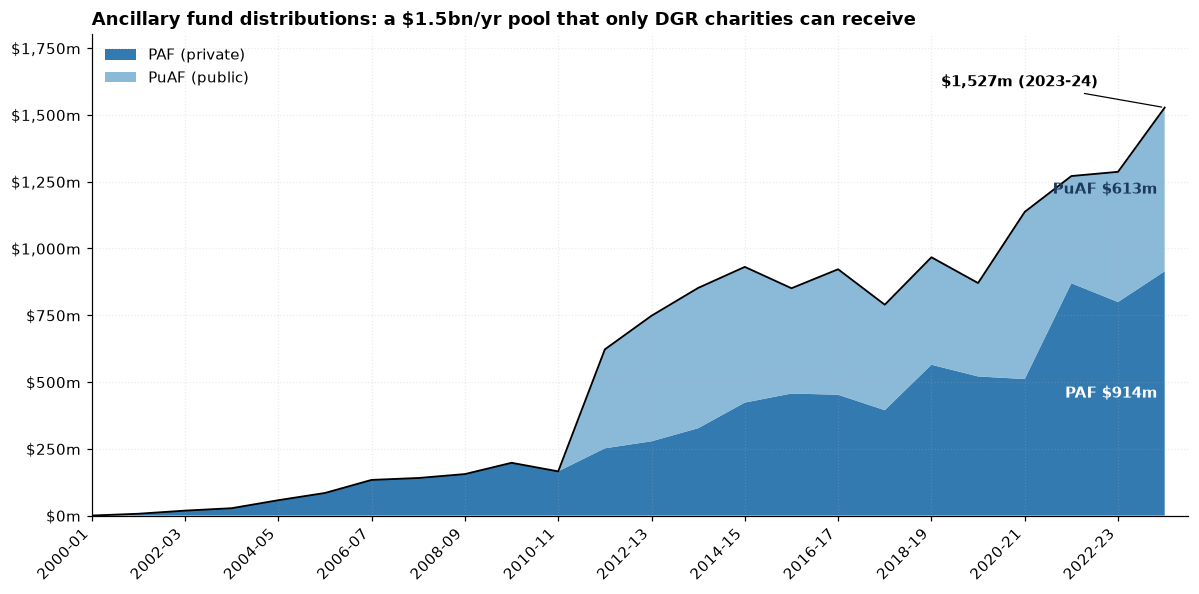

In [11]:
# Chart 1 — pool trend: distributions out, by fund type
trend = anc.pivot_table(index="income_year", columns="fund_type",
                        values="distributions_made", aggfunc="sum").fillna(0)[["PAF", "PuAF"]] / 1e6

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(trend))
ax.stackplot(x, trend["PAF"], trend["PuAF"],
             labels=["PAF (private)", "PuAF (public)"],
             colors=[C["paf"], C["puaf"]], alpha=0.9)
tot = trend.sum(axis=1)
ax.plot(x, tot, color="black", lw=1.2)

ax.annotate(f"${tot.iloc[-1]:,.0f}m ({trend.index[-1]})",
            xy=(x[-1], tot.iloc[-1]), xytext=(-95, 14), textcoords="offset points",
            fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="-", color="black", lw=0.8))
ax.text(x[-1] - 0.15, trend["PAF"].iloc[-1] / 2, f"PAF ${trend['PAF'].iloc[-1]:,.0f}m",
        ha="right", va="center", color="white", fontweight="bold")
ax.text(x[-1] - 0.15, trend["PAF"].iloc[-1] + trend["PuAF"].iloc[-1] / 2,
        f"PuAF ${trend['PuAF'].iloc[-1]:,.0f}m", ha="right", va="center",
        color="#1b3a5c", fontweight="bold")

ax.set_xticks(x[::2], trend.index[::2], rotation=45, ha="right")
ax.set_xlim(0, len(trend) - 0.5)
ax.set_ylim(0, tot.max() * 1.18)
fmt_m(ax, "y")
ax.set_title("Ancillary fund distributions: a \\$1.5bn/yr pool that only DGR charities can receive")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 2. The fence: who is allowed to receive it today

Only 40% of charities with current financials hold DGR, but they account for 78% of donations and 62% of revenue. The 60% locked out are overwhelmingly the smaller, less-fundable charities.


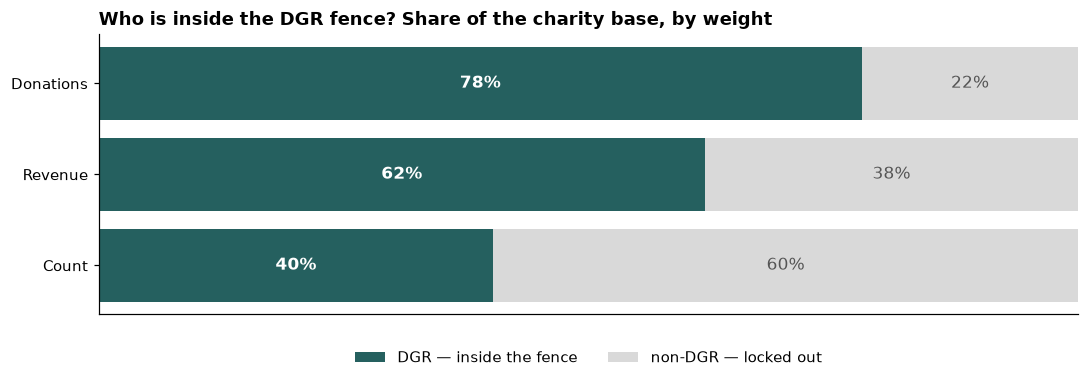

In [12]:
# Chart 2 — the DGR fence, under each weighting
fence = pd.DataFrame({"in": weights(m[m["has_dgr"]]), "all": weights(m)})
share = (100 * fence["in"] / fence["all"]).reindex(RULE_ORDER)

fig, ax = plt.subplots(figsize=(10, 3.6))
y = np.arange(len(share))
ax.barh(y, share, color=C["incumbent"], label="DGR — inside the fence")
ax.barh(y, 100 - share, left=share, color=C["outside"], label="non-DGR — locked out")

for i, v in enumerate(share):
    ax.text(v / 2, i, f"{v:.0f}%", va="center", ha="center",
            color="white", fontweight="bold", fontsize=11)
    ax.text(v + (100 - v) / 2, i, f"{100 - v:.0f}%", va="center", ha="center",
            color="#555", fontsize=11)

ax.set_yticks(y, [RULE_LABEL[r] for r in share.index])
ax.set_xlim(0, 100)
ax.set_xticks([])
ax.grid(False)
ax.set_title("Who is inside the DGR fence? Share of the charity base, by weight")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncols=2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 3. The result: four scenarios × three allocation rules

We can't observe who actually receives the pool (the ATO never publishes it), so each scenario assumes a mechanical sharing rule: pool split in proportion to **donations** received, total **revenue**, or equally per charity (**count**). The scenarios change only 'who is eligible': 
1. nobody changes (status quo)
2. the PC's redesign (gainers in, ~2,700 losers out)
3. the expansion model (gainers in, nobody out)
4. every charity gets DGR(outer bound).

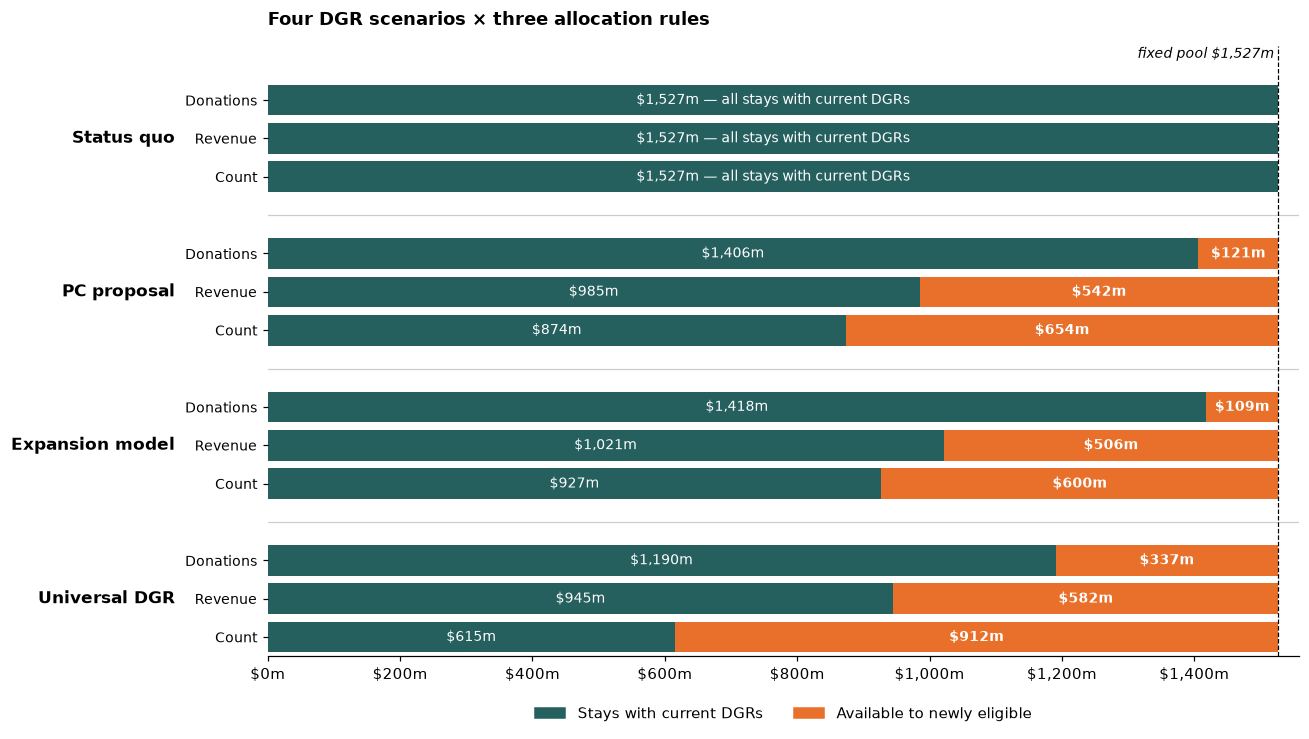

The donations rule is the most plausible floor (funds follow demonstrated fundability);
the count rule is an upper bound on access, not a likely flow.


In [13]:
# Chart 3 — the fixed pool under all four scenarios, by allocation rule
fig, ax = plt.subplots(figsize=(12, 6.8))
GAPH = 1.0
ypos, ylabels, dividers = [], [], []
yc = 0.0
for scen_name in SCEN_ORDER:
    d = res[res["scenario"] == scen_name].set_index("rule").reindex(RULE_ORDER)
    for rule in RULE_ORDER:
        inc, gn = d.loc[rule, "incumbent_$m"], d.loc[rule, "gainer_$m"]
        ax.barh(yc, inc, color=C["incumbent"])
        ax.barh(yc, gn, left=inc, color=C["new"])
        if gn > 0:
            ax.text(inc + gn / 2, yc, f"${gn:,.0f}m", va="center", ha="center",
                    color="white", fontweight="bold", fontsize=9)
            ax.text(inc / 2, yc, f"${inc:,.0f}m", va="center", ha="center",
                    color="white", fontsize=9)
        else:
            ax.text(inc / 2, yc, f"${inc:,.0f}m — all stays with current DGRs",
                    va="center", ha="center", color="white", fontsize=9)
        ypos.append(yc)
        ylabels.append(RULE_LABEL[rule])
        yc += 1
    ax.text(-0.09, yc - 2, scen_name, transform=ax.get_yaxis_transform(),
            fontweight="bold", fontsize=11, ha="right", va="center")
    dividers.append(yc - 0.5)
    yc += GAPH

for dv in dividers[:-1]:
    ax.axhline(dv + GAPH / 2, color="#ccc", lw=0.8)
ax.axvline(POOL / 1e6, color="black", lw=0.8, ls="--")
ax.text(POOL / 1e6, -1.1, f"fixed pool ${POOL/1e6:,.0f}m ", ha="right", fontsize=9,
        style="italic")

ax.set_yticks(ypos, ylabels, fontsize=9)
ax.set_xlim(0, POOL / 1e6 * 1.02)
ax.set_ylim(yc - GAPH - 0.5, -1.4)
fmt_m(ax)
ax.grid(False)
ax.spines["left"].set_visible(False)
ax.set_title("Four DGR scenarios × three allocation rules",
             pad=14)
ax.legend(handles=[Patch(color=C["incumbent"], label="Stays with current DGRs"),
                   Patch(color=C["new"], label="Available to newly eligible")],
          loc="upper center", bbox_to_anchor=(0.5, -0.06), ncols=2)
plt.tight_layout()
plt.show()

print("The donations rule is the most plausible floor (funds follow demonstrated fundability);\n"
      "the count rule is an upper bound on access, not a likely flow.")


## 4. Why expansion beats pure change

The PC's pure change and the Expansion model let in the **same gainers**. The difference is the ~2,700 charities that lose DGR under pure change (and hence access to the pool). Expansion model buys a "nobody loses" for a small reduction in what gainers can access (i.e. not a material difference between the two scenarios)


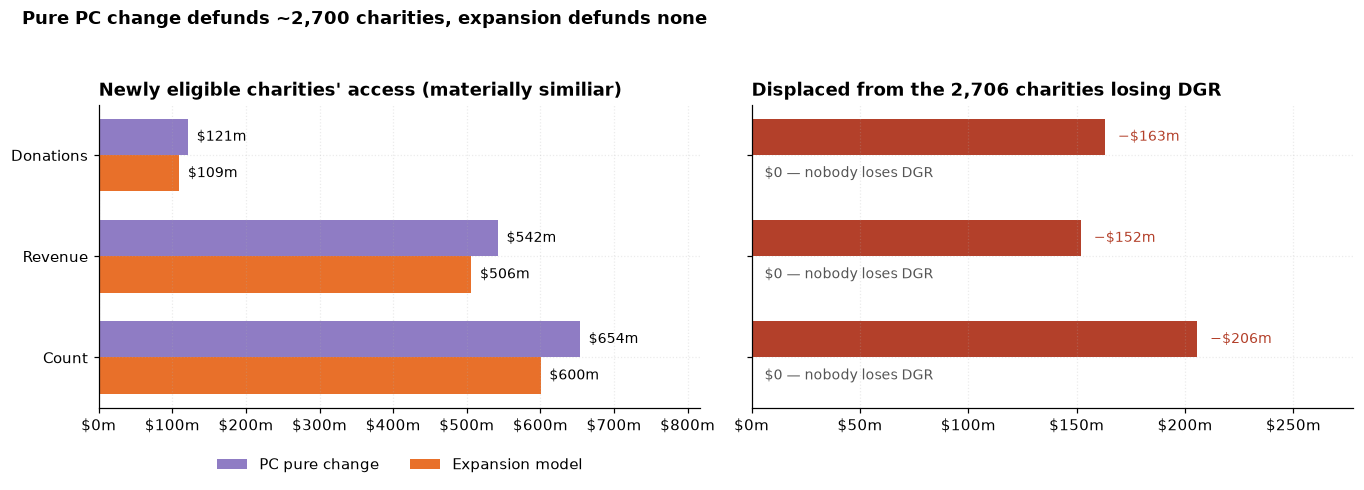

In [16]:
# Chart 4 — gainer access is nearly identical; only pure change displaces incumbents
pc_g = res[res["scenario"] == "PC proposal"].set_index("rule")["gainer_$m"].reindex(RULE_ORDER)
un_g = res[res["scenario"] == "Expansion model"].set_index("rule")["gainer_$m"].reindex(RULE_ORDER)
disp = displaced.reindex(RULE_ORDER)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
y = np.arange(len(RULE_ORDER))
h = 0.36

ax1.barh(y - h / 2, pc_g, height=h, color="#8f7cc4", label="PC pure change")
ax1.barh(y + h / 2, un_g, height=h, color=C["new"], label="Expansion model")
for yi, (a, b) in enumerate(zip(pc_g, un_g)):
    ax1.text(a + 12, yi - h / 2, f"${a:,.0f}m", va="center", fontsize=9)
    ax1.text(b + 12, yi + h / 2, f"${b:,.0f}m", va="center", fontsize=9)
ax1.set_yticks(y, [RULE_LABEL[r] for r in RULE_ORDER])
ax1.invert_yaxis()
ax1.set_xlim(0, pc_g.max() * 1.25)
fmt_m(ax1)
ax1.set_title("Newly eligible charities' access (materially similiar)")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=2)

ax2.barh(y - h / 2, disp, height=h, color=C["neg"], label="PC pure change")
ax2.barh(y + h / 2, [0] * len(y), height=h, color=C["new"])
for yi, v in enumerate(disp):
    ax2.text(v + 6, yi - h / 2, f"−${v:,.0f}m", va="center", fontsize=9, color=C["neg"])
    ax2.text(6, yi + h / 2, "$0 — nobody loses DGR", va="center", fontsize=9, color="#555")
ax2.set_xlim(0, disp.max() * 1.35)
fmt_m(ax2)
ax2.set_title(f"Displaced from the {len(losers):,} charities losing DGR")

fig.suptitle("Pure PC change defunds ~2,700 charities, expansion defunds none",
             fontweight="bold", x=0.02, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## The fine print

- **Access, not predicted $ flow.** Real granting is relationship-driven and difficult to model well. These figures set bounds on what newly eligible charities could access, not what they will receive.
- **Hard ceiling check passes.** Ancillary grants arrive as donations in recipients' AIS returns, so a group's actual reported donations caps what it could absorb. Every scenario × rule cell stays under the gainers' ceiling (the PC count-rule figure sits at 93% of it; the count-rule numbers are  essentially bounds).
- **The pool survives reform.** The eligibility mapping flags ~1,200 ancillary funds as PC losers, but the PC final report explicitly retains ancillary funds ("giving funds") with DGR intact; we override those flags, so the \$1,527m pool is assumed intact under every scenario.
